# 1(a)

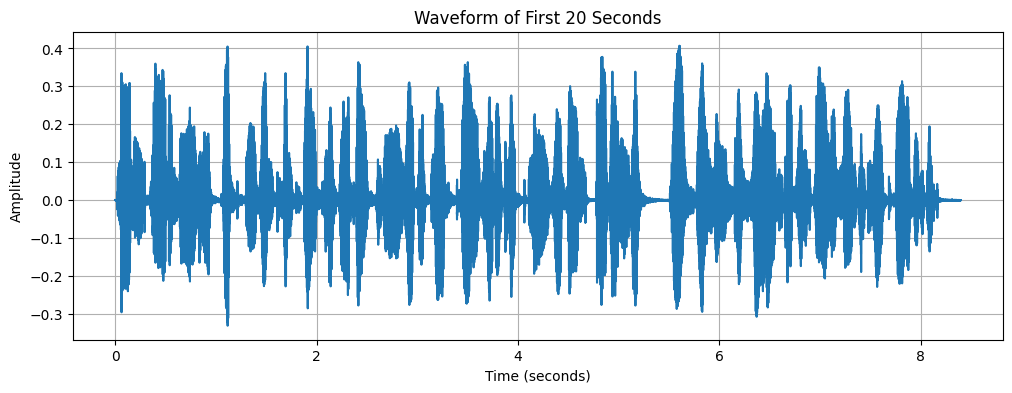

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

file_path = "LJ025-0076.wav"
signal, fs = librosa.load(file_path, sr=16000)

duration = 20
samples = duration * fs
signal_20 = signal[:samples]

time = np.arange(len(signal_20)) / fs

plt.figure(figsize=(12,4))
plt.plot(time, signal_20)
plt.title("Waveform of First 20 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# 1(b)

In [2]:
frame_length_ms = 25
frame_shift_ms = 10

frame_length = int(frame_length_ms * fs / 1000)
frame_shift = int(frame_shift_ms * fs / 1000)

num_frames = int((len(signal_20) - frame_length) / frame_shift) + 1

print(frame_length)
print(frame_shift)
print(num_frames)

400
160
838


# 1(c)

In [3]:
frames = []

for i in range(num_frames):
    start = i * frame_shift
    end = start + frame_length
    frame = signal_20[start:end]
    frames.append(frame)

frames = np.array(frames)

print(frames.shape)

(838, 400)


# 1(d)

In [5]:
import numpy as np

hamming_window = np.hamming(frame_length)

STE = []
STM = []
ZCR = []
AUTOCORR = []
AMDF = []
AMSDF = []

max_lag = frame_length // 2

for frame in frames:

    windowed = frame * hamming_window

    ste = np.sum(windowed ** 2)
    STE.append(ste)

    stm = np.sum(np.abs(windowed))
    STM.append(stm)

    zcr = np.sum(np.abs(np.diff(np.sign(windowed)))) / (2 * len(windowed))
    ZCR.append(zcr)

    autocorr_frame = []
    amdf_frame = []
    amsdf_frame = []

    for lag in range(max_lag):

        autocorr_val = np.sum(windowed[:len(windowed)-lag] * windowed[lag:])
        autocorr_frame.append(autocorr_val)

        amdf_val = np.sum(np.abs(windowed[:len(windowed)-lag] - windowed[lag:]))
        amdf_frame.append(amdf_val)

        amsdf_val = np.sum((windowed[:len(windowed)-lag] - windowed[lag:]) ** 2)
        amsdf_frame.append(amsdf_val)

    AUTOCORR.append(autocorr_frame)
    AMDF.append(amdf_frame)
    AMSDF.append(amsdf_frame)

STE = np.array(STE)
STM = np.array(STM)
ZCR = np.array(ZCR)
AUTOCORR = np.array(AUTOCORR)
AMDF = np.array(AMDF)
AMSDF = np.array(AMSDF)

print(STE.shape)
print(STM.shape)
print(ZCR.shape)
print(AUTOCORR.shape)
print(AMDF.shape)
print(AMSDF.shape)

(838,)
(838,)
(838,)
(838, 200)
(838, 200)
(838, 200)


# 1(e)

In [7]:
import numpy as np

frame_length_ms = 25
frame_shift_ms = 10

frame_length = int(frame_length_ms * fs / 1000)
frame_shift = int(frame_shift_ms * fs / 1000)

num_frames_rect = int((len(signal_20) - frame_length) / frame_shift) + 1

rect_window = np.ones(frame_length)

frames_rect = []

for i in range(num_frames_rect):
    start = i * frame_shift
    end = start + frame_length
    frame = signal_20[start:end]
    windowed_frame = frame * rect_window
    frames_rect.append(windowed_frame)

frames_rect = np.array(frames_rect)

print("Frame length:", frame_length)
print("Frame shift:", frame_shift)
print("Total number of frames using rectangular window:", num_frames_rect)
print("Shape of rectangular window frames:", frames_rect.shape)

Frame length: 400
Frame shift: 160
Total number of frames using rectangular window: 838
Shape of rectangular window frames: (838, 400)


# 1(f)

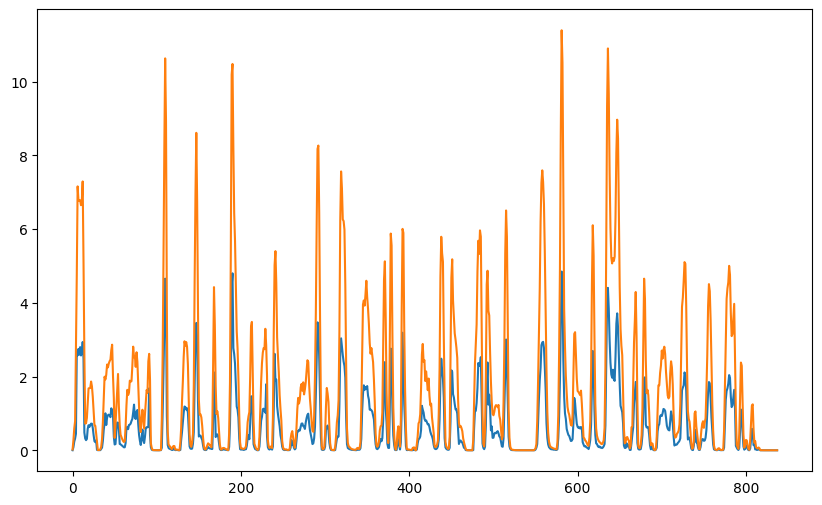

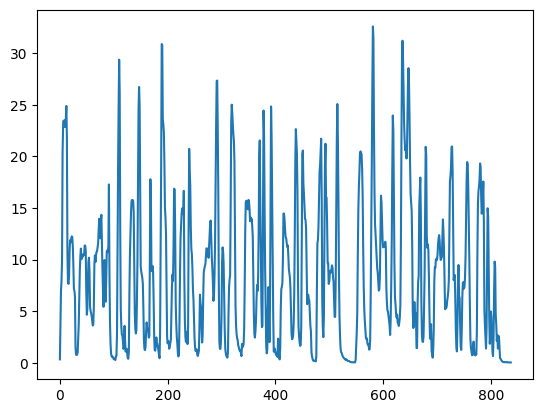

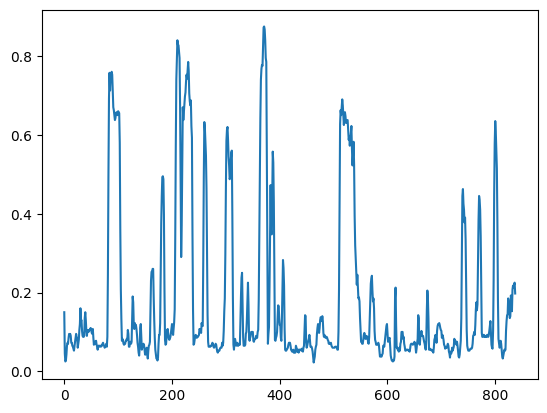

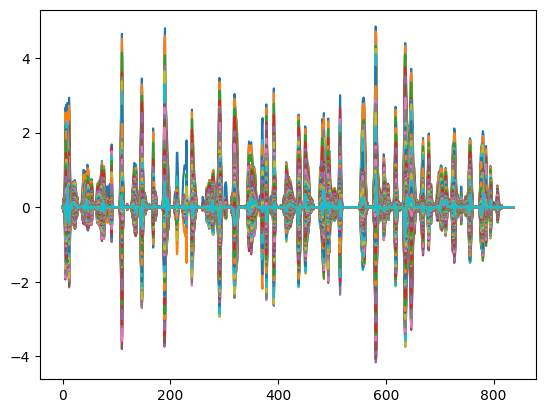

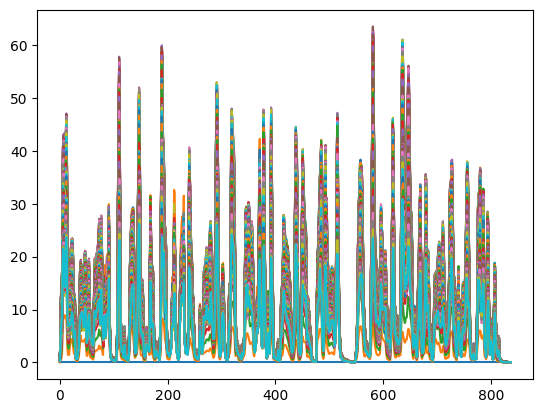

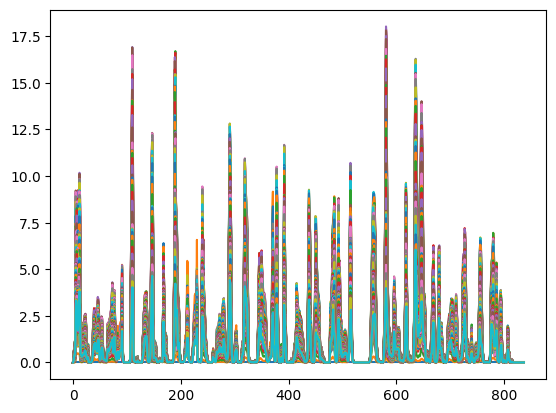

In [8]:
plt.figure(figsize=(10,6))
plt.plot(STE)
plt.plot(STE_rect)
plt.show()

plt.figure()
plt.plot(STM)
plt.show()

plt.figure()
plt.plot(ZCR)
plt.show()

plt.figure()
plt.plot(AUTOCORR)
plt.show()

plt.figure()
plt.plot(AMDF)
plt.show()

plt.figure()
plt.plot(AMSDF)
plt.show()

# 1(g)

Voiced speech has high energy, low ZCR, strong autocorrelation, low AMDF and AMSDF. Unvoiced speech has low energy, high ZCR, weak autocorrelation, high AMDF and AMSDF.

# 1(h)

Hamming window provides smoother features and better discrimination. Rectangular window produces less smooth features.

# TASK -2

# 2(a)

In [13]:
threshold = np.mean(AUTOCORR)

periodic_frames = AUTOCORR > threshold

periodic_indices = np.where(periodic_frames == True)[0]

periodic_values = AUTOCORR[periodic_indices]

final_periodic_frames = frames[periodic_indices]

print("Threshold value:", threshold)
print("Periodic frame indices:", periodic_indices)
print("Number of periodic frames:", len(periodic_indices))
print("Autocorrelation values of periodic frames:", periodic_values)
print("Shape of periodic frames:", final_periodic_frames.shape)

Threshold value: 0.0015465957087504596
Periodic frame indices: [  1   1   1 ... 816 816 816]
Number of periodic frames: 61241
Autocorrelation values of periodic frames: [[ 8.26232147e-02  8.21043707e-02  8.06041278e-02 ... -2.51949683e-03
  -2.18436513e-03 -1.84746283e-03]
 [ 8.26232147e-02  8.21043707e-02  8.06041278e-02 ... -2.51949683e-03
  -2.18436513e-03 -1.84746283e-03]
 [ 8.26232147e-02  8.21043707e-02  8.06041278e-02 ... -2.51949683e-03
  -2.18436513e-03 -1.84746283e-03]
 ...
 [ 1.33352182e-02  1.30977940e-02  1.24962989e-02 ...  3.29498730e-06
   4.24038362e-05  9.99298545e-05]
 [ 1.33352182e-02  1.30977940e-02  1.24962989e-02 ...  3.29498730e-06
   4.24038362e-05  9.99298545e-05]
 [ 1.33352182e-02  1.30977940e-02  1.24962989e-02 ...  3.29498730e-06
   4.24038362e-05  9.99298545e-05]]
Shape of periodic frames: (61241, 400)


# 2(b)

Periodicity appears as peaks in autocorrelation and minima in AMDF and AMSDF.

# 2(c)

Voiced frames have higher energy and lower ZCR. Unvoiced frames have lower energy and higher ZCR.

In [14]:
energy_threshold = np.mean(STE)
zcr_threshold = np.mean(ZCR)

voiced_indices = np.where((STE > energy_threshold) & (ZCR < zcr_threshold))[0]

unvoiced_indices = np.where((STE <= energy_threshold) & (ZCR >= zcr_threshold))[0]

voiced_frames = frames[voiced_indices]
unvoiced_frames = frames[unvoiced_indices]

print("Energy threshold:", energy_threshold)
print("ZCR threshold:", zcr_threshold)

print("Voiced frame indices:", voiced_indices)
print("Number of voiced frames:", len(voiced_indices))

print("Unvoiced frame indices:", unvoiced_indices)
print("Number of unvoiced frames:", len(unvoiced_indices))

print("Shape of voiced frames:", voiced_frames.shape)
print("Shape of unvoiced frames:", unvoiced_frames.shape)

Energy threshold: 0.6650340277314861
ZCR threshold: 0.1844480906921241
Voiced frame indices: [  5   6   7   8   9  10  11  12  13  19  21  22  23  38  39  40  41  42
  43  44  45  46  47  48  53  54  67  68  69  70  71  72  73  74  75  76
  77  78 107 108 109 110 111 112 131 132 133 134 135 136 137 145 146 147
 148 149 167 168 169 187 188 189 190 191 192 193 194 195 196 197 239 240
 241 242 243 244 245 272 273 277 278 279 280 281 289 290 291 292 293 294
 317 318 319 320 321 322 323 324 325 344 345 346 347 348 349 350 351 352
 353 354 355 356 357 358 378 379 380 391 392 393 394 395 415 416 417 418
 419 420 421 422 423 436 437 438 439 440 441 449 450 451 452 453 454 455
 456 457 478 479 480 481 482 483 484 485 486 491 492 493 494 495 496 553
 554 555 556 557 558 559 560 561 562 563 578 579 580 581 582 583 584 585
 586 595 596 597 598 599 616 617 618 619 620 633 634 635 636 637 638 639
 640 641 642 643 644 645 646 647 648 649 650 651 652 653 654 667 668 669
 670 678 679 680 681 697 698 69

# TASK - 3

# 3(a)

In [15]:
pitch_period_autocorr = []
pitch_period_amdf = []
pitch_period_amsdf = []

max_lag = frame_length // 2

for frame in frames:

    autocorr = np.correlate(frame, frame, mode='full')
    autocorr = autocorr[len(autocorr)//2:]

    search_region_autocorr = autocorr[1:max_lag]
    peak_index = np.argmax(search_region_autocorr) + 1
    pitch_period_autocorr.append(peak_index)

    amdf = []
    amsdf = []

    for lag in range(1, max_lag):

        diff = frame[:-lag] - frame[lag:]

        amdf.append(np.sum(np.abs(diff)))
        amsdf.append(np.sum(diff**2))

    amdf = np.array(amdf)
    amsdf = np.array(amsdf)

    min_index_amdf = np.argmin(amdf) + 1
    min_index_amsdf = np.argmin(amsdf) + 1

    pitch_period_amdf.append(min_index_amdf)
    pitch_period_amsdf.append(min_index_amsdf)

pitch_period_autocorr = np.array(pitch_period_autocorr)
pitch_period_amdf = np.array(pitch_period_amdf)
pitch_period_amsdf = np.array(pitch_period_amsdf)

print("Pitch period using Autocorrelation:")
print(pitch_period_autocorr)

print("Pitch period using AMDF:")
print(pitch_period_amdf)

print("Pitch period using AMSDF:")
print(pitch_period_amsdf)

Pitch period using Autocorrelation:
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  3  3 11  2  3  5  5  5  5  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  4  3  3  3  3  3  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  3  3 11 11  2  9  7  2  5  2
  3  3  2  2  2  3 33  7 15 34  3  9  9  9  9  2  9  5  7  5  3  3  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  5  3  3  3  3  3
  8  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  4  9  9  5  3  3  4  4  4  3  3  5  5
  1  1  1  1  1

# 3(b)

In [12]:
pitch_frequency = fs / pitch_periods

print(pitch_frequency)

[16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         16000.
 16000.         16000.         16000.         

# TASK - 4

# 4(a)

Voiced speech has high energy, low ZCR and periodic structure. Unvoiced speech has low energy, high ZCR and noise-like structure.

# 4(b)

Autocorrelation detects repeating patterns. AMDF and AMSDF detect minimum difference corresponding to pitch period.

# 4(c)

Autocorrelation and AMSDF are most reliable. AMDF is moderately reliable. Energy and ZCR are less reliable.